# Generating correlated samples of Mass Action parameters 

Nathaniel Linden (UCSD MAE) - March  2023

In [43]:
import sunode
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import sympy as sym
from SALib.sample import sobol as sobol_samp
from SALib.sample import morris as morris_samp
from SALib.analyze import sobol as sobol_analyze
from SALib.analyze import morris as morris_analyze
import corner
# import colorcet
import sys
import time
sys.path.insert(0, '../odes')

import ampk_MA_single_mech as model1
%matplotlib inline
plt.style.use('~/.matplotlib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True

## Defining bounds for the parameters and unknown initial conditions

In [60]:
############################################
# First for Mass action parameters
nominal_vals_MA = [
   2.5e-3, # KdAMP
   1.5e-3, # KdADP
   1.7e-3, # KdATP
   90.467, # kOnCaMKK = (koff+kphos/Km)
   0.357, # kPhosCaMKK
   0.742, # kOnLKB1
   3.92e-2, # kPhosLKB1
   16.56, # kOnPP
   1.1e-1, # kDephosPP
   1569.59, # kOnAMPK
   6.33, # kPhosAMPK
   16.56, # kOnPP1
   1.1e-1, # kDephosPP1
   1e-3, # AMPKAR
]

bounds_MA_90 = [[0.1*param, 1.9*param] for param in nominal_vals_MA]

param_names_MA = ['KdAMP', 'KdADP', 'KdATP', 'kOnCaMKK', 'kPhosCaMKK', 
               'kOnLKB1','kPhosLKB1','kOnPP','kDephosPP', 
               'kOnAMPK','kPhosAMPK', 'kOnPP1','kDephosPP1', 'AMPKAR']
# dictionary of the problem for SALib
problem_MA_90 = {'num_vars':14, 'names':param_names_MA, 'bounds': bounds_MA_90,}

############################################
# Now for the Michaelis-Menten parameters
nominal_vals_MM = [
   2.5e-3, # KdAMP
   1.5e-3, # KdADP
   1.7e-3, # KdATP
   0.357, # kPhosCaMKK
   1.5e-2,  # KmCaMKK
   3.92e-2, # kPhosLKB1
   1.4,  # KmLKB1
   1.1e-1, # kDephosPP
   6.7e-2, # KmPP
   6.33, # kPhosAMPK
   4.67e-3, # KmAMPK
   1.1e-1, # kDephosPP1
   6.7e-2, # KmPP1
   1e-3, # AMPKAR
]

bounds_MM_90 = [[0.1*param, 1.9*param] for param in nominal_vals_MM]

param_names_MM = ['KdAMP', 'KdADP', 'KdATP', 'kPhosCaMKK', 'KmCamKK', 'kPhosLKB1', 'KmLKB1', 'kDephosPP', 'KmPP', 'kPhosAMPK', 'KmAMPK', 
               'kDephosPP1', 'KmPP1', 'AMPKAR']

# dictionary of the problem for SALib
problem_MM_90 = {'num_vars':14, 'names':param_names_MM, 'bounds': bounds_MM_90,}

############################################
# Random seed
seed = np.random.seed(seed=2048)

Now draw the samples using the Morris and Sobol sampling methods. We will sample both the Mass action and Michealis-Menten parameters and then use the definitions of the MM parameters to generate correlated samples of the MA parameters

In [64]:
# generate samples using the Saltelli and Morris sampling methods
nsamps = 2**7
param_vals_sobol_MA = sobol_samp.sample(problem_MA_90, nsamps, calc_second_order=False, seed=seed)
param_vals_morris_MA = morris_samp.sample(problem_MA_90, nsamps, seed=seed)
param_vals_sobol_MM = sobol_samp.sample(problem_MM_90, nsamps, calc_second_order=False, seed=seed)
param_vals_morris_MM = morris_samp.sample(problem_MM_90, nsamps, seed=seed)

Computing MA params from the MM params:
- kcat = Vmax/Et (Assume all Et is 1.0 mM)
- Fix kon to 1, so koff = Km - kcat
- Fix koff to 1, so kon = (1 + kcat)/Km


In [66]:
# copy MA to np arrays
param_vals_sobol_MA_corr = np.array(param_vals_sobol_MA)
param_vals_morris_MA_corr = np.array(param_vals_morris_MA)
param_vals_sobol_MM_np = np.array(param_vals_sobol_MM)
param_vals_morris_MM_np = np.array(param_vals_morris_MM)

# now compute all kons using samples of Km and from the MM model and Kcat from MA model
kcat_idxs_MA = [4,6,8,10,12]
kon_idxs_MA = [3,5,7,9,11]
km_idxs_MM = [4,6,8,10,12]
for kcat_i, kon_i, km_i in zip(kcat_idxs_MA, kon_idxs_MA, km_idxs_MM):
    param_vals_sobol_MA_corr[:,kon_i] = (1+param_vals_sobol_MA_corr[:,kcat_i])/param_vals_sobol_MM_np[:,km_i]
for kcat_i, kon_i, km_i in zip(kcat_idxs_MA, kon_idxs_MA, km_idxs_MM):  
    param_vals_morris_MA_corr[:,kon_i] = (1+param_vals_morris_MA_corr[:,kcat_i])/param_vals_morris_MM_np[:,km_i]

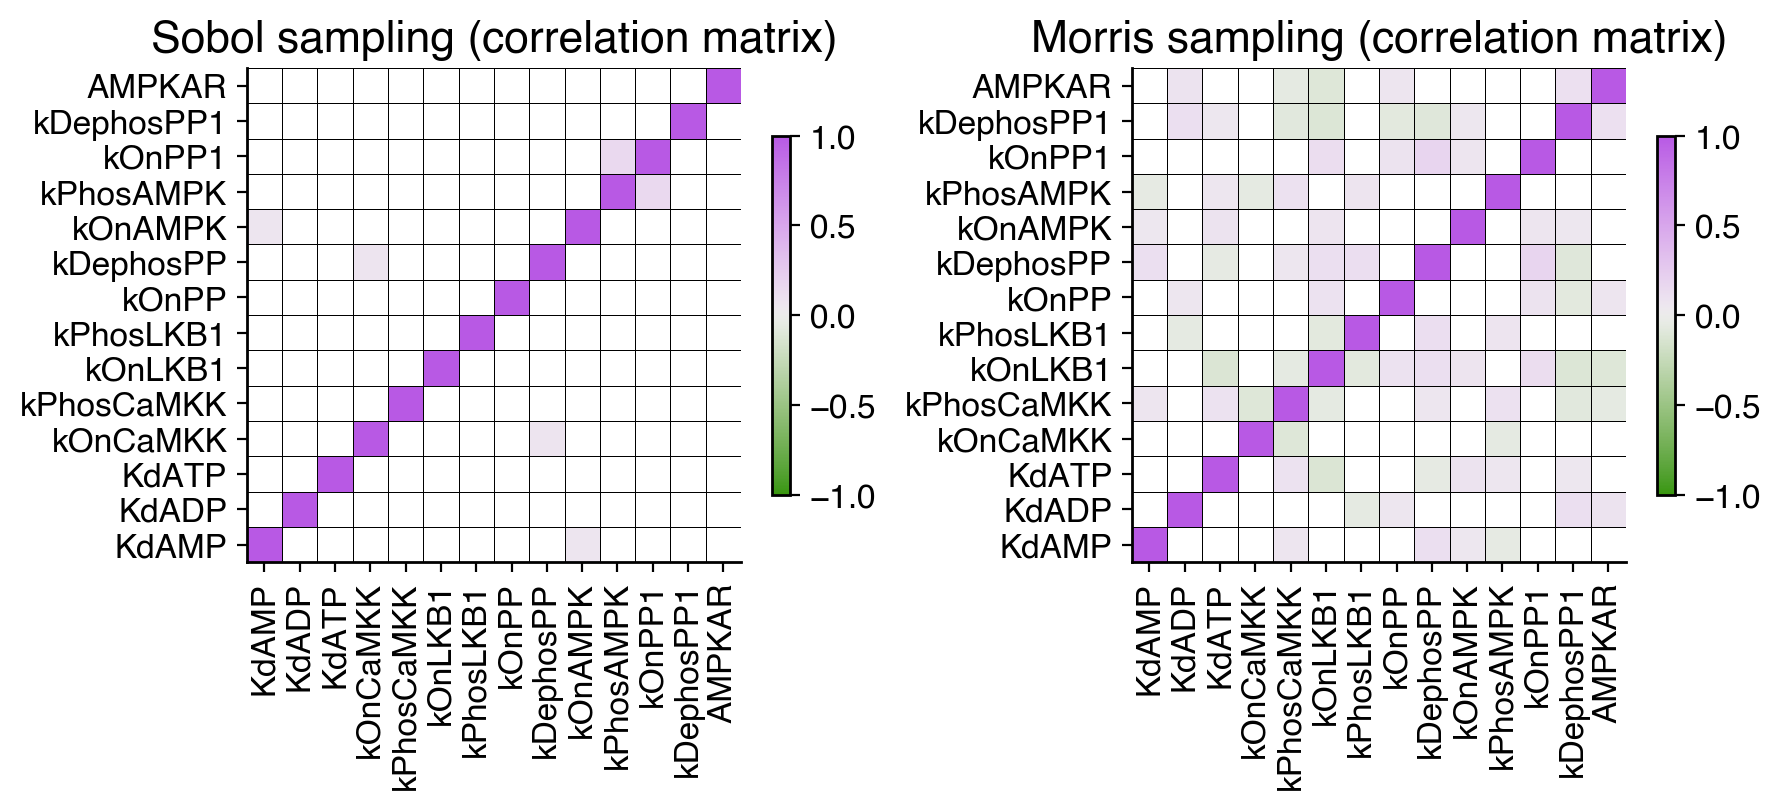

In [104]:
thresh = 0.05
sobol_corrcoef = np.corrcoef(param_vals_sobol_MA.T)
sobol_corrcoef[np.abs(sobol_corrcoef) <=thresh] = np.nan
morris_corrcoef = np.corrcoef(param_vals_morris_MA.T)
morris_corrcoef[np.abs(morris_corrcoef) <=thresh] = np.nan

fig, ax = plt.subplots(1,2, figsize=(9,4.5))
pos0 = ax[0].pcolormesh(sobol_corrcoef, cmap='cet_CET_D2', edgecolors='k', linewidths=0.25, vmin=-1.0, vmax=1.0)
pos1 = ax[1].pcolormesh(morris_corrcoef, cmap='cet_CET_D2', edgecolors='k', linewidths=0.25, vmin=-1.0, vmax=1.0)
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[0].set_title('Sobol sampling (correlation matrix)')
ax[1].set_title('Morris sampling (correlation matrix)')
ax[0].set_xticks(np.arange(0.5, 14.5, 1))
ax[0].set_xticklabels(param_names_MA, rotation=90)
ax[0].set_yticks(np.arange(0.5, 14.5, 1))
ax[0].set_yticklabels(param_names_MA)
ax[1].set_xticks(np.arange(0.5, 14.5, 1))
ax[1].set_xticklabels(param_names_MA, rotation=90)
ax[1].set_yticks(np.arange(0.5, 14.5, 1))
ax[1].set_yticklabels(param_names_MA)
fig.colorbar(pos0, ax=ax[0], shrink=0.5)
fig.colorbar(pos1, ax=ax[1], shrink=0.5)

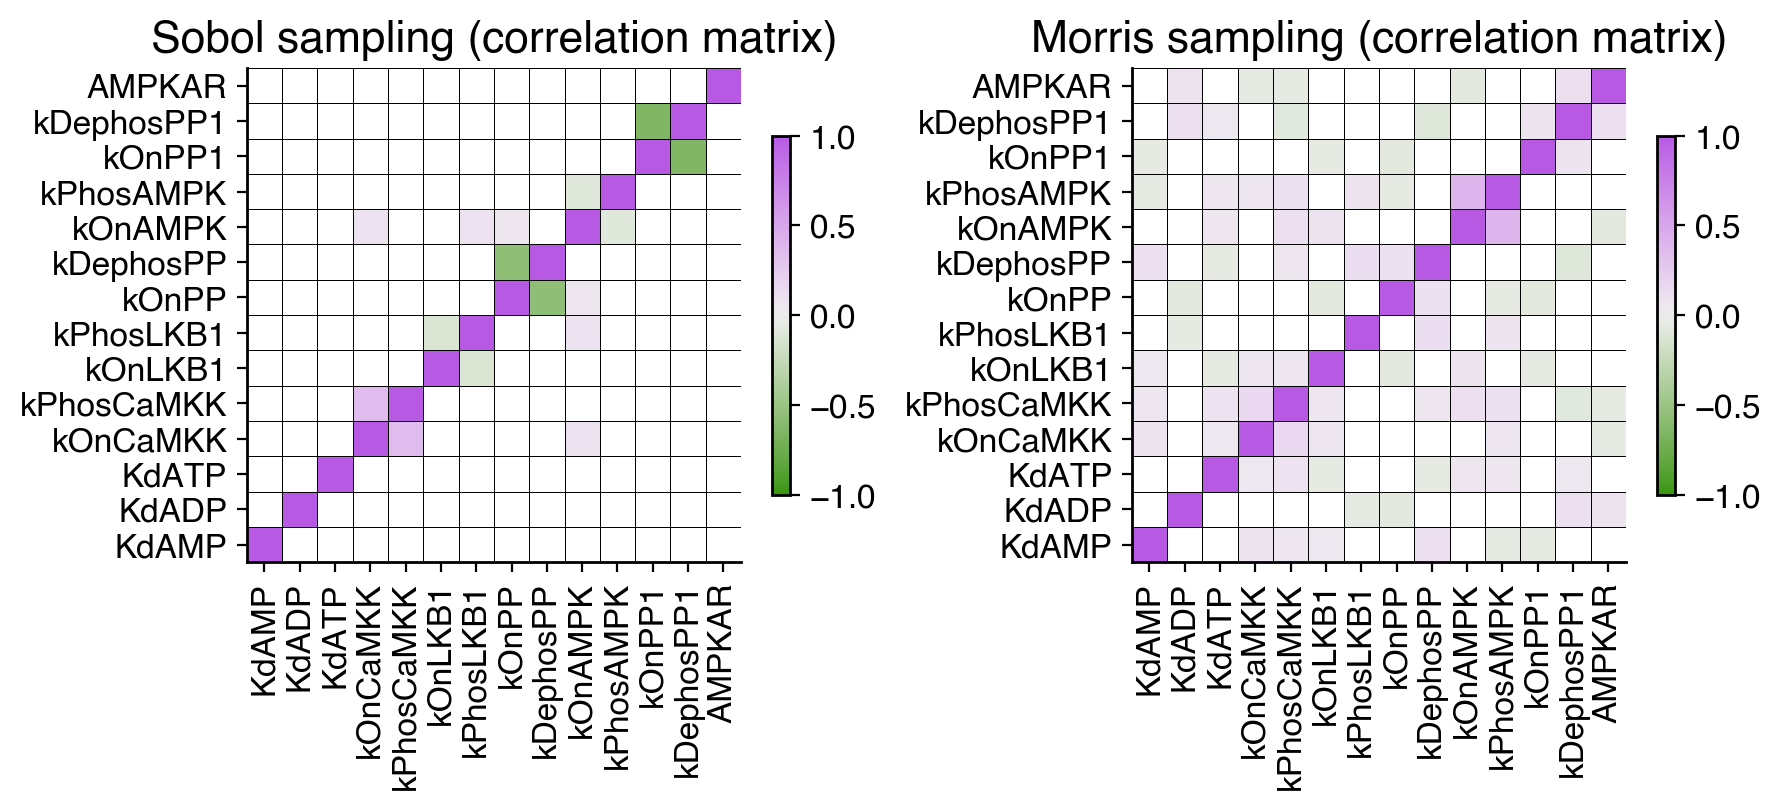

In [105]:
thresh = 0.05
sobol_corr_corrcoef = np.corrcoef(param_vals_sobol_MA_corr.T)
sobol_corr_corrcoef[np.abs(sobol_corr_corrcoef) <=thresh] = np.nan
morris_corr_corrcoef = np.corrcoef(param_vals_morris_MA_corr.T)
morris_corr_corrcoef[np.abs(morris_corr_corrcoef) <=thresh] = np.nan
fig, ax = plt.subplots(1,2, figsize=(9,4.5))
pos0 = ax[0].pcolormesh(sobol_corr_corrcoef, cmap='cet_CET_D2', edgecolors='k', linewidths=0.25, vmin=-1.0, vmax=1.0)
pos1 = ax[1].pcolormesh(morris_corr_corrcoef, cmap='cet_CET_D2', edgecolors='k', linewidths=0.25, vmin=-1.0, vmax=1.0)
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[0].set_title('Sobol sampling (correlation matrix)')
ax[1].set_title('Morris sampling (correlation matrix)')
ax[0].set_xticks(np.arange(0.5, 14.5, 1))
ax[0].set_xticklabels(param_names_MA, rotation=90)
ax[0].set_yticks(np.arange(0.5, 14.5, 1))
ax[0].set_yticklabels(param_names_MA)
ax[1].set_xticks(np.arange(0.5, 14.5, 1))
ax[1].set_xticklabels(param_names_MA, rotation=90)
ax[1].set_yticks(np.arange(0.5, 14.5, 1))
ax[1].set_yticklabels(param_names_MA)
fig.colorbar(pos0, ax=ax[0], shrink=0.5)
fig.colorbar(pos1, ax=ax[1], shrink=0.5)

### What happens if we use groups for the correlated parameters?
- This is suggested by Jacques et al. 2006 (https://www.sciencedirect.com/science/article/pii/S0951832005002231) as a way to apply variance-based methods to problems with correlated inputs.
- I am curious how this effects the sampling, etc...

In [102]:
# first define a new problem with the groups of parameters
param_groups_MA = ['KdAMP','KdADP','KdATP','CaMKK','CaMKK','LKB1','LKB1','PP','PP',
                   'AMPK','AMPK','PP1','PP1','AMPKAR']
param_names_MA = ['KdAMP', 'KdADP', 'KdATP', 'kOnCaMKK', 'kPhosCaMKK', 
               'kOnLKB1','kPhosLKB1','kOnPP','kDephosPP', 
               'kOnAMPK','kPhosAMPK', 'kOnPP1','kDephosPP1', 'AMPKAR']
problem_MA_90_grouped = {'num_vars':14, 
                         'names':param_names_MA, 
                         'groups':param_groups_MA,
                         'bounds': bounds_MA_90,}
param_vals_sobol_MA_grouped = sobol_samp.sample(problem_MA_90_grouped, nsamps, calc_second_order=False, seed=seed)
param_vals_morris_MA_grouped = morris_samp.sample(problem_MA_90_grouped, nsamps, seed=seed)

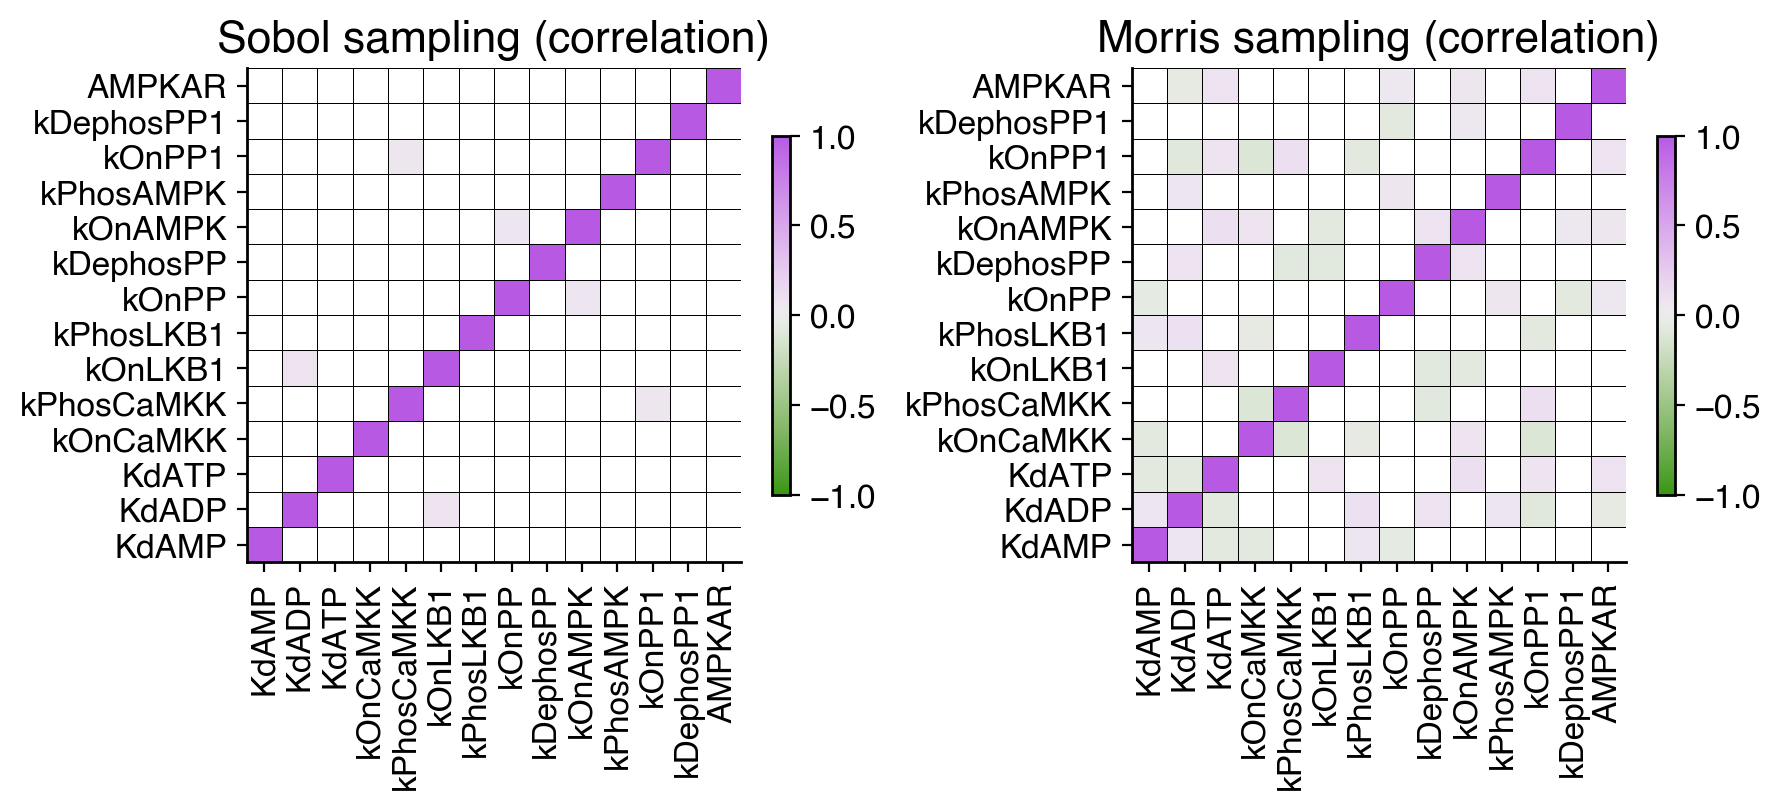

In [103]:
thresh = 0.05
sobol_corr_corrcoef = np.corrcoef(param_vals_sobol_MA_grouped.T)
sobol_corr_corrcoef[np.abs(sobol_corr_corrcoef) <=thresh] = np.nan
morris_corr_corrcoef = np.corrcoef(param_vals_morris_MA_grouped.T)
morris_corr_corrcoef[np.abs(morris_corr_corrcoef) <=thresh] = np.nan
fig, ax = plt.subplots(1,2, figsize=(9,4.5))
pos0 = ax[0].pcolormesh(sobol_corr_corrcoef, cmap='cet_CET_D2', edgecolors='k', linewidths=0.25, vmin=-1.0, vmax=1.0)
pos1 = ax[1].pcolormesh(morris_corr_corrcoef, cmap='cet_CET_D2', edgecolors='k', linewidths=0.25, vmin=-1.0, vmax=1.0)
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[0].set_title('Sobol sampling (correlation)')
ax[1].set_title('Morris sampling (correlation)')
ax[0].set_xticks(np.arange(0.5, 14.5, 1))
ax[0].set_xticklabels(param_names_MA, rotation=90)
ax[0].set_yticks(np.arange(0.5, 14.5, 1))
ax[0].set_yticklabels(param_names_MA)
ax[1].set_xticks(np.arange(0.5, 14.5, 1))
ax[1].set_xticklabels(param_names_MA, rotation=90)
ax[1].set_yticks(np.arange(0.5, 14.5, 1))
ax[1].set_yticklabels(param_names_MA)
fig.colorbar(pos0, ax=ax[0], shrink=0.5)
fig.colorbar(pos1, ax=ax[1], shrink=0.5)

I am struggling to figure ou how to introduce the correct correlations when using the grouped sampling... 
Previously, we computed the same number of MM and MA samples and used MM samples to construct correlated MA samples. 
However, since we use the grouped sampling here, that will not be a simple.